# Circadian Rhythm
Kailin Liu, Melody Yazdi, Richard Zhang

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Base Model

In [3]:
# Circadian oscillator parameters
mu = 0.23        # nonlinearity
beta = 0.0075    # light sensitivity 0.0075
pi = 2 * np.pi / 24  # circadian frequency (radians/hour)

# Melatonin PK parameters
ka = 1.0         # absorption rate (1/hr)
ke = 0.3         # elimination rate (1/hr)

# PD parameters
Emax = 1.0      # max melatonin effect on oscillator (like light input); set 0.01
EC50 = 1.0       # half-max concentration (arbitrary units)

# Light schedule
def light_input(t):
    # Light on from 6am to 10pm (zeitgeber time 6 to 22)
    t_mod = t % 24
    return 1000.0 if 6 <= t_mod < 22 else 0.0

def dose_function(t, dose_times, dose_amount=1.0):
    return sum(dose_amount for t_dose in dose_times if np.isclose(t, t_dose, atol=0.1))

def circadian_melatonin_model(t, y, dose_times):
    G, M, x, y_osc = y
    D = dose_function(t, dose_times)
    L_light = light_input(t)
    L_mel = Emax * M / (EC50 + M)
    L_total = L_light + L_mel
    dGdt = D - ka * G
    dMdt = ka * G - ke * M
    dxdt = pi * (y_osc + mu * (x - (4/3)*x**3))
    dydt = pi * (-x + beta * L_total * (1 - x**2) * y_osc)

    return [dGdt, dMdt, dxdt, dydt]

def light_input_dark(t):
    return 0.0

def kronauer_model(t, y):
    x, y_osc = y
    L_light = light_input(t)
    L_total = L_light
    dxdt = pi * (y_osc + mu * (x - (4/3)*x**3))
    dydt = pi * (-x + beta * L_total * (1 - x**2) * y_osc)
    return [dxdt, dydt]

def kronauer_model_dark(t, y):
    x, y_osc = y
    L_lightd = light_input_dark(t)
    L_total = L_lightd

    dxdt = pi * (y_osc + mu * (x - (4/3)*x**3))
    dydt = pi * (-x + beta * L_total * (1 - x**2) * y_osc)

    return [dxdt, dydt]

# Investigating Different Solvers: RK45 and Radau
No visible difference was observed between the two solvers on the Kronauer model (no melatonin intervention), but a difference was observed on a small dosage, shown below.

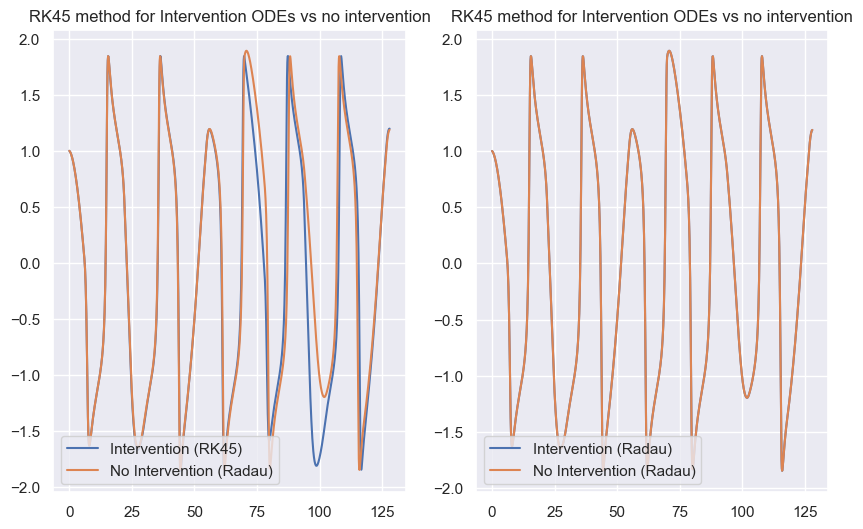

In [8]:
y0 = [0.0, 0.0, 1.0, 0.0]  # Start on limit cycle
dose_times = [20]
t_span = (0, 128)
t_eval = np.linspace(*t_span, 1000)
# Radau
sol = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
# RK45
solrk = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,), t_eval=t_eval, method='RK45')
# compare with kronauer model (no melatonin dosage)
y0k = [1.0,0.0]
solk = solve_ivp(kronauer_model, t_span, y0k,
                args=(), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)

t = sol.t
G, M, x, y_osc = sol.y #Radau
G, M, xrk, yrk_osc = solrk.y #Runge-Kutta
xk, yk_osc = solk.y #Kronauer

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
#plt.plot(t, x, label='Intervention (Radau)')
#plt.plot(t, y_osc, label='Coupled Oscillator (intervention)')
plt.plot(t, xrk, label='Intervention (RK45)')
#plt.plot(t, yk_osc, label='Coupled Oscillator')
plt.plot(t, xk, label='No Intervention (Radau)')
plt.title('RK45 method for Intervention ODEs vs no intervention')
plt.legend(loc='lower left')

plt.subplot(1, 2, 2)
plt.plot(t, x, label='Intervention (Radau)')
#plt.plot(t, y_osc, label='Coupled Oscillator (intervention)')
#plt.plot(t, xrk, label='Intervention (RK45)')
#plt.plot(t, yk_osc, label='Coupled Oscillator')
plt.plot(t, xk, label='No Intervention (Radau)')
plt.title('RK45 method for Intervention ODEs vs no intervention')
plt.legend(loc='lower left')


# Creating a Phase Shift
When we used the RK45 solver, the shift in phase due to intervention appeared to happen much later than the dose. However, this was due to numerical error